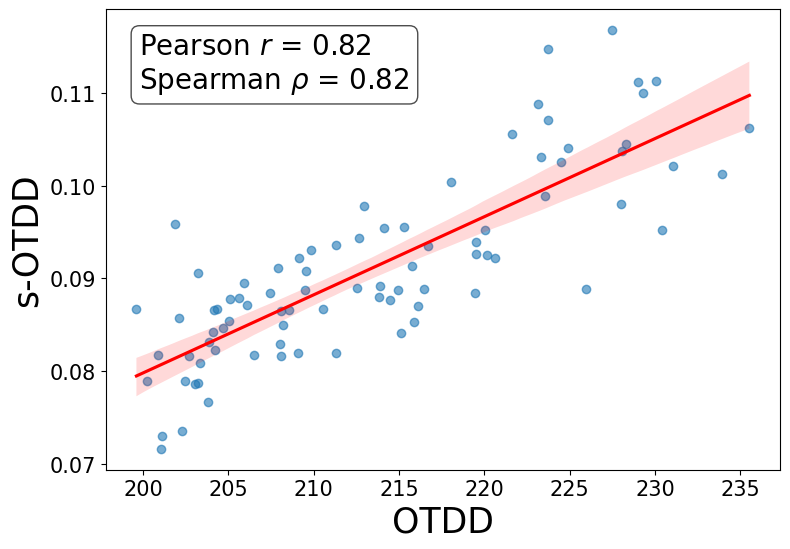

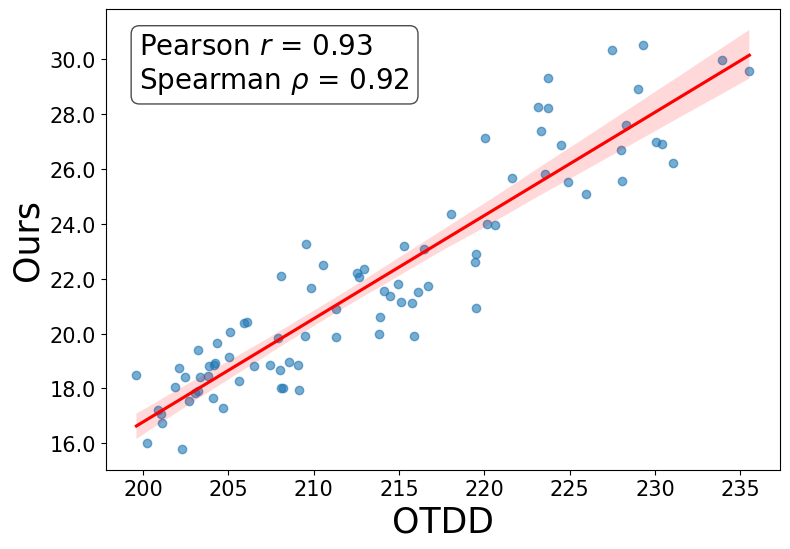

In [1]:
import torch
import os
import scipy.stats
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter

def four_symbols(x, pos):
    return f"{x:.5f}"[:4]  




def plot_corr(x, y, title, savename=None):
    # Convert to numpy for scipy/statsmodels
    x_np, y_np = x.numpy(), y.numpy()
    
    # Compute correlations
    pearson_r, pearson_p = stats.pearsonr(x_np, y_np)
    spearman_r, spearman_p = stats.spearmanr(x_np, y_np)
    
    # Make plot
    plt.figure(figsize=(.8*10, .7 *8))
    ax = sns.regplot(x=x_np, y=y_np, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
    
    # Add text box with stats
    textstr = '\n'.join((
        rf'Pearson $r$ = {pearson_r:.2f}',# (p={pearson_p:.1e})',
        rf'Spearman $ρ$ = {spearman_r:.2f}',# (p={spearman_p:.1e})'
    ))
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
            fontsize=20, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    #plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:.4g}')) # 2 decimal places
    ax.yaxis.set_major_formatter(FuncFormatter(four_symbols))
    ax.set_xlabel("OTDD", size=25)
    ax.set_ylabel(title, size=25)
    ax.tick_params(labelsize=15)
    plt.tight_layout()
    if savename is not None:
        plt.savefig(savename)
    plt.show()
    
path = "correlation/MNIST/"
dir_ls = [path + subdir for subdir in os.listdir(path)] # "/seed_6_size_6000/exact_otdd_dist.pt"
otdd_name = "/exact_otdd_dist.pt"
otdd_ls = []
sotdd_name = "/sotdd_10000_dist.pt"
sotdd_ls = []
my_sotdd_name = "/my_sotdd_dist.pt"
my_sotdd_ls = []
for subdir in dir_ls:
    try:
        ot_data = torch.load(subdir + otdd_name)[0, 1]
        sot_data = torch.load(subdir + sotdd_name)[0, 1]
        my_sotdd_data = torch.load(subdir + my_sotdd_name)[0, 1]
        
        otdd_ls.append(ot_data)
        sotdd_ls.append(sot_data)
        my_sotdd_ls.append(my_sotdd_data)
    except:
        pass

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch

# Sort by ot_vals
ot_vals, idx = torch.sort(torch.tensor(otdd_ls))
sot_vals = torch.tensor(sotdd_ls)[idx]
#got_vals = torch.tensor(gotdd_ls)[idx]
my_sotdd_vals = torch.tensor(my_sotdd_ls)[idx]



# Call for each
plot_corr(ot_vals, sot_vals, "s-OTDD", savename="correlation/MNIST_sOTDD.png")
plot_corr(ot_vals, my_sotdd_vals, "Ours", savename="correlation/MNIST_ours.png")


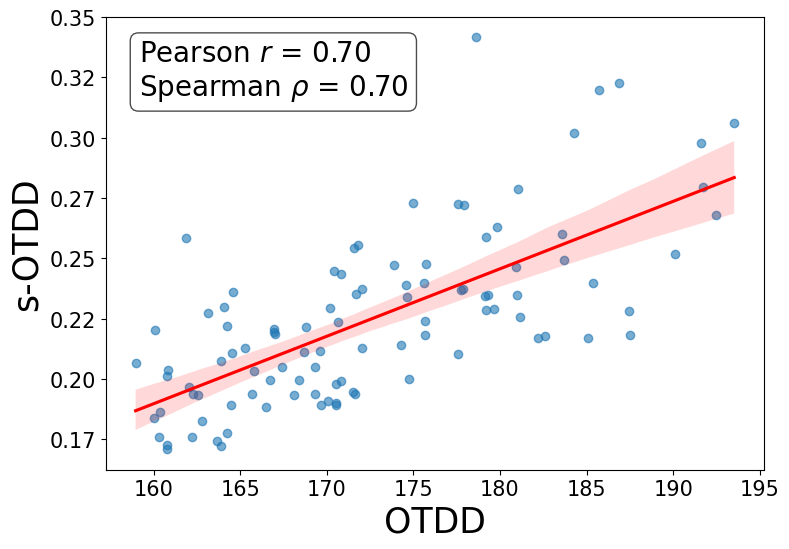

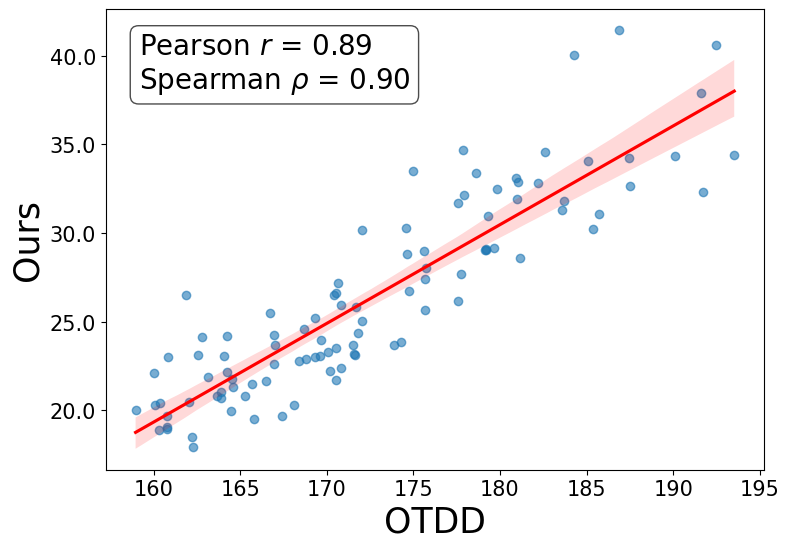

In [2]:
import torch
import os
import scipy.stats

path = "correlation/FashionMNIST/"
dir_ls = [path + subdir for subdir in os.listdir(path)] # "/seed_6_size_6000/exact_otdd_dist.pt"
otdd_name = "/exact_otdd_dist.pt"
otdd_ls = []
sotdd_name = "/sotdd_10000_dist.pt"
sotdd_ls = []
my_sotdd_name = "/my_sotdd_dist.pt"
my_sotdd_ls = []
for subdir in dir_ls:
    try:
        ot_data = torch.load(subdir + otdd_name)[0, 1]
        sot_data = torch.load(subdir + sotdd_name)[0, 1]
        my_sotdd_data = torch.load(subdir + my_sotdd_name)[0, 1]
        
        otdd_ls.append(ot_data)
        sotdd_ls.append(sot_data)
        my_sotdd_ls.append(my_sotdd_data)
    except:
        pass

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch

# Sort by ot_vals
ot_vals, idx = torch.sort(torch.tensor(otdd_ls))
sot_vals = torch.tensor(sotdd_ls)[idx]
#got_vals = torch.tensor(gotdd_ls)[idx]
my_sotdd_vals = torch.tensor(my_sotdd_ls)[idx]



# Call for each
plot_corr(ot_vals, sot_vals, "s-OTDD", "correlation/FashionMNIST_sOTDD.png")
plot_corr(ot_vals, my_sotdd_vals, "Ours", "correlation/FashionMNIST_ours.png")

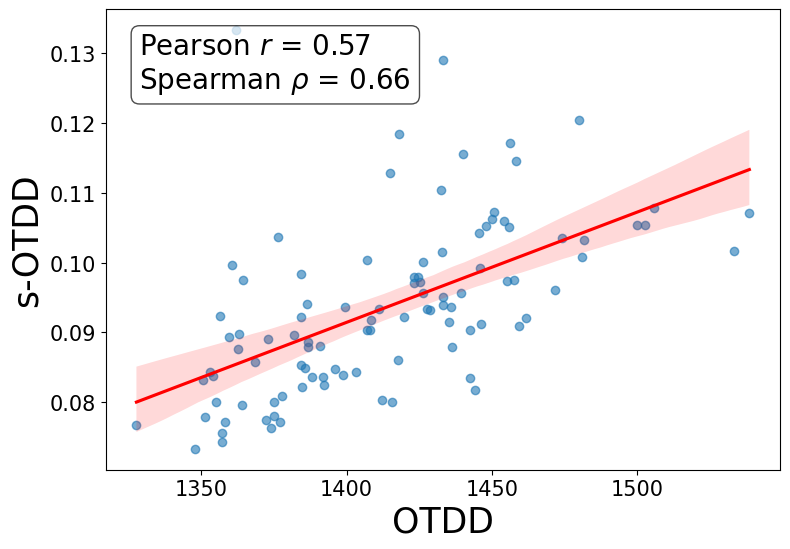

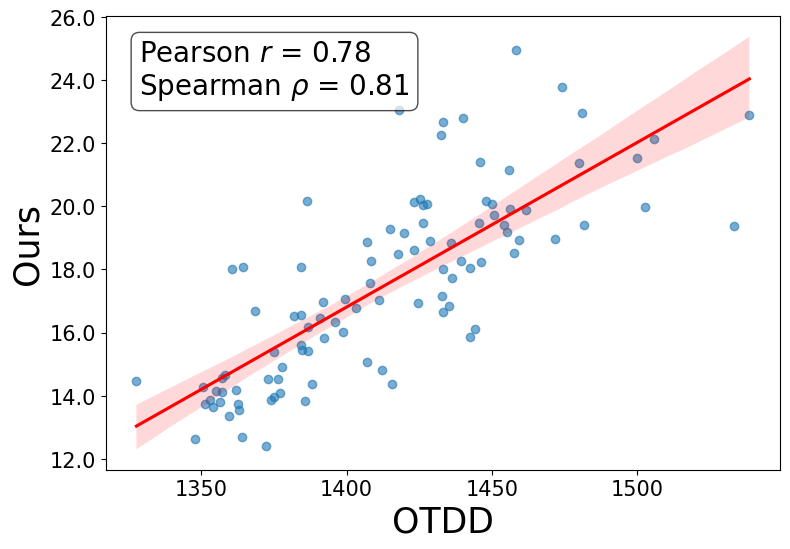

In [3]:
import torch
import os
import scipy.stats

path = "correlation/CIFAR10/"
dir_ls = [path + subdir for subdir in os.listdir(path)] # "/seed_6_size_6000/exact_otdd_dist.pt"
otdd_name = "/exact_otdd_dist.pt"
otdd_ls = []
sotdd_name = "/sotdd_10000_dist.pt"
sotdd_ls = []
my_sotdd_name = "/my_sotdd_dist.pt"
my_sotdd_ls = []
for subdir in dir_ls:
    try:
        ot_data = torch.load(subdir + otdd_name)[0, 1]
        sot_data = torch.load(subdir + sotdd_name)[0, 1]
        my_sotdd_data = torch.load(subdir + my_sotdd_name)[0, 1]
        
        otdd_ls.append(ot_data)
        sotdd_ls.append(sot_data)
        my_sotdd_ls.append(my_sotdd_data)
    except:
        pass

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch

# Sort by ot_vals
ot_vals, idx = torch.sort(torch.tensor(otdd_ls))
sot_vals = torch.tensor(sotdd_ls)[idx]
#got_vals = torch.tensor(gotdd_ls)[idx]
my_sotdd_vals = torch.tensor(my_sotdd_ls)[idx]



# Call for each
plot_corr(ot_vals, sot_vals, "s-OTDD", "correlation/CIFAR10_sOTDD.png")
plot_corr(ot_vals, my_sotdd_vals, "Ours", "correlation/CIFAR10_ours.png")